## 1. Import thư viện


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway, ttest_ind, kruskal
from itertools import combinations
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

print('Thư viện đã sẵn sàng')

Thư viện đã sẵn sàng


## 2. Đọc & chuẩn bị dữ liệu


In [2]:
df = pd.read_csv('raw_long_cleaned.csv')

MONTHS = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
QUARTERS = ['Q1','Q2','Q3','Q4']

df_monthly = df[df['period'].isin(MONTHS)].copy()
df_monthly['period'] = pd.Categorical(df_monthly['period'], categories=MONTHS, ordered=True)
df_monthly['month_num'] = df_monthly['period'].cat.codes + 1

# Pivot: mỗi vật liệu là một cột, mỗi tháng là 1 dòng
pivot = df_monthly.pivot_table(index='period', columns='name', values='value', aggfunc='sum')
pivot = pivot.reindex(MONTHS)

print(f' {df.shape[0]} dòng | {df["name"].nunique()} vật liệu | {len(MONTHS)} tháng')
df_monthly.head(6)

 204 dòng | 12 vật liệu | 12 tháng


,name,unit,period,value,month_num
0,Limestone,ton,Jan,1185.21,1
1,Clay,ton,Jan,6280.95,1
2,Sand,ton,Jan,0.00,1
3,Gypsum,ton,Jan,0.00,1
4,Laterite,ton,Jan,0.00,1
5,Cement,ton,Jan,0.00,1


## 3. Tổng quan nhanh


In [3]:
print('Missing values:'); print(df.isnull().sum())
print()
print('Thống kê mô tả theo vật liệu (tháng Jan–Dec):')
display(
    df_monthly.groupby('name')['value'].agg(
        Count='count', Mean='mean', Std='std', Min='min', Median='median', Max='max', Total='sum'
    ).round(2).sort_values('Total', ascending=False)
)

Missing values:
name      0
unit      0
period    0
value     0
dtype: int64

Thống kê mô tả theo vật liệu (tháng Jan–Dec):


,Count,Mean,Std,Min,Median,Max,Total
name,,,,,,,
Clay,12,10312.07,2642.28,4812.60,11176.55,13526.18,123744.82
Limestone,12,1845.14,487.69,903.63,1969.48,2501.26,22141.64
Feldspar,12,1257.29,558.42,627.90,1052.50,2458.17,15087.46
Glazing,12,1097.39,292.45,593.12,1223.87,1532.65,13168.66
Recycled Mat,12,986.12,287.54,364.14,1005.80,1428.32,11833.49
Cement,12,0.00,0.00,0.00,0.00,0.00,0.00
Aggregate,12,0.00,0.00,0.00,0.00,0.00,0.00
Gypsum,12,0.00,0.00,0.00,0.00,0.00,0.00
Laterite,12,0.00,0.00,0.00,0.00,0.00,0.00


## 4. Xu hướng theo tháng & Heatmap


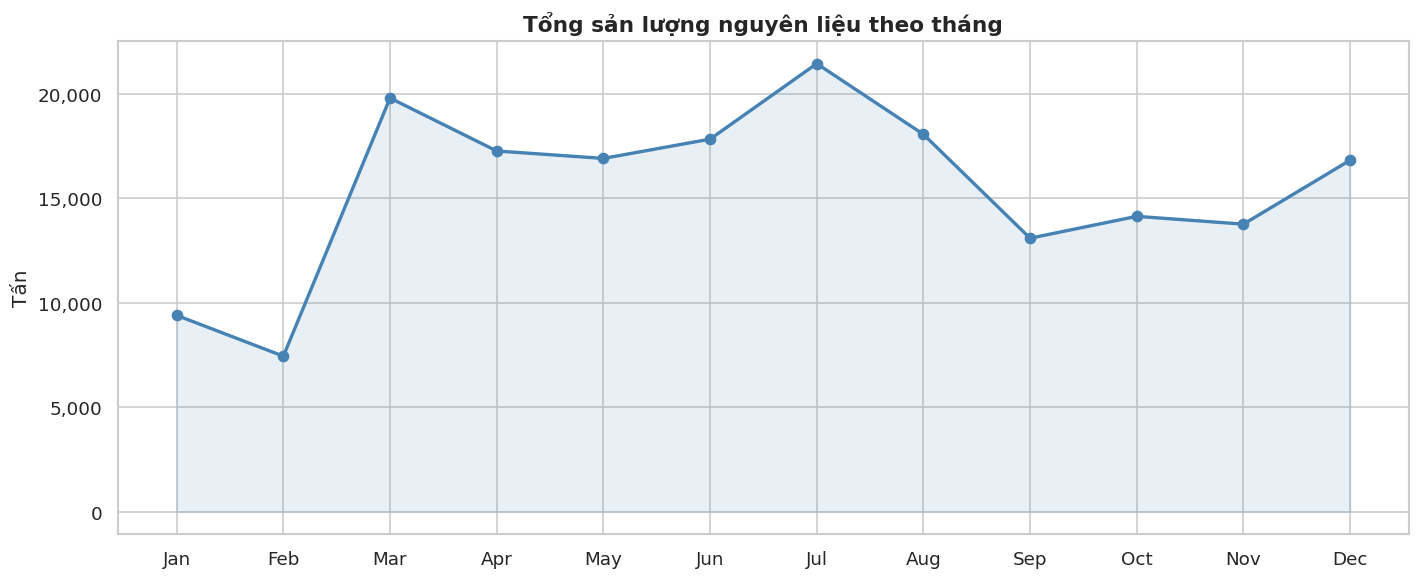

In [4]:
# Tổng sản lượng theo tháng
monthly_total = df_monthly.groupby('period')['value'].sum()

fig, ax = plt.subplots()
ax.plot(monthly_total.index.astype(str), monthly_total.values, marker='o', linewidth=2, color='steelblue')
ax.fill_between(monthly_total.index.astype(str), monthly_total.values, alpha=0.12, color='steelblue')
ax.set_title('Tổng sản lượng nguyên liệu theo tháng', fontsize=13, fontweight='bold')
ax.set_ylabel('Tấn')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
plt.tight_layout(); plt.show()

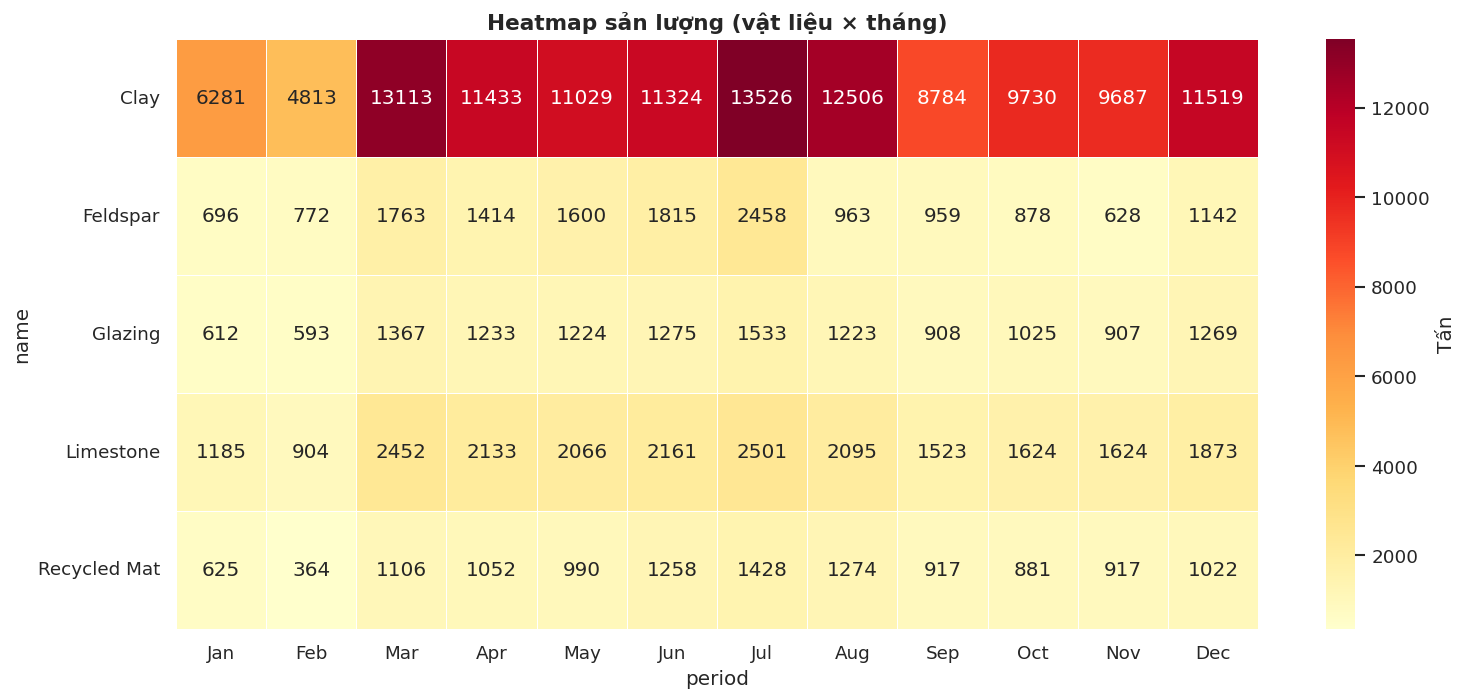

In [5]:
active_cols = pivot.columns[pivot.sum() > 0]
fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(pivot[active_cols].T, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.4, ax=ax, cbar_kws={'label': 'Tấn'})
ax.set_title('Heatmap sản lượng (vật liệu × tháng)', fontsize=13, fontweight='bold')
plt.yticks(rotation=0); plt.tight_layout(); plt.show()

## 5. Ma trận tương quan — Pearson


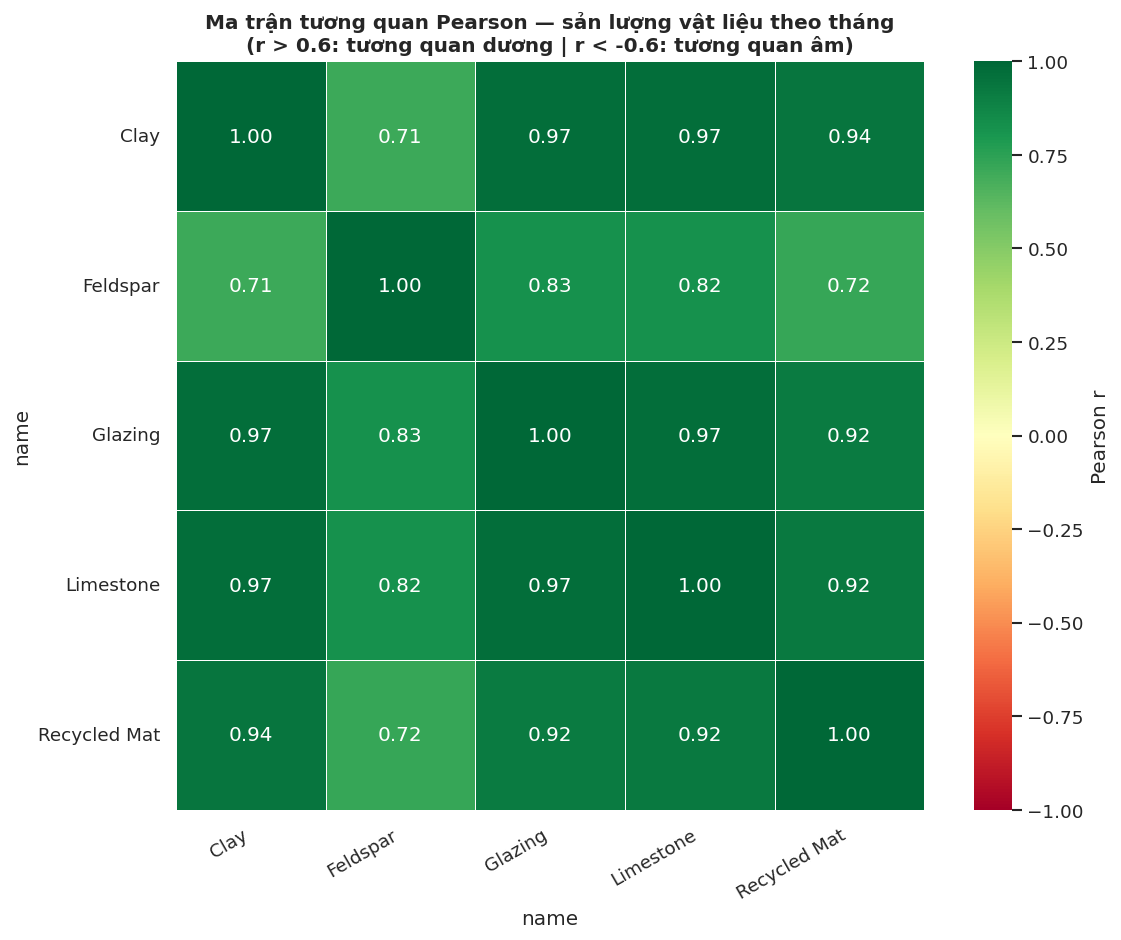

In [6]:
corr = pivot[active_cols].corr(method='pearson')

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1,
            linewidths=0.5, square=True, ax=ax,
            cbar_kws={'label': 'Pearson r'})
ax.set_title('Ma trận tương quan Pearson — sản lượng vật liệu theo tháng\n'
             '(r > 0.6: tương quan dương | r < -0.6: tương quan âm)',
             fontsize=12, fontweight='bold')
plt.xticks(rotation=30, ha='right'); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

In [7]:
# Liệt kê các cặp tương quan mạnh
corr_pairs = []
for c1, c2 in combinations(active_cols, 2):
    r = corr.loc[c1, c2]
    corr_pairs.append({'Vật liệu A': c1, 'Vật liệu B': c2, 'Pearson r': round(r, 3)})

df_corr = pd.DataFrame(corr_pairs).sort_values('Pearson r', key=abs, ascending=False)

print('TOP 10 cặp tương quan mạnh nhất:')
display(df_corr.head(10))
print()
strong_pos = df_corr[df_corr['Pearson r'] > 0.6]
strong_neg = df_corr[df_corr['Pearson r'] < -0.6]

TOP 10 cặp tương quan mạnh nhất:


,Vật liệu A,Vật liệu B,Pearson r
2,Clay,Limestone,0.973
7,Glazing,Limestone,0.970
1,Clay,Glazing,0.969
3,Clay,Recycled Mat,0.941
9,Limestone,Recycled Mat,0.924
8,Glazing,Recycled Mat,0.916
4,Feldspar,Glazing,0.828
5,Feldspar,Limestone,0.822
6,Feldspar,Recycled Mat,0.721
0,Clay,Feldspar,0.707


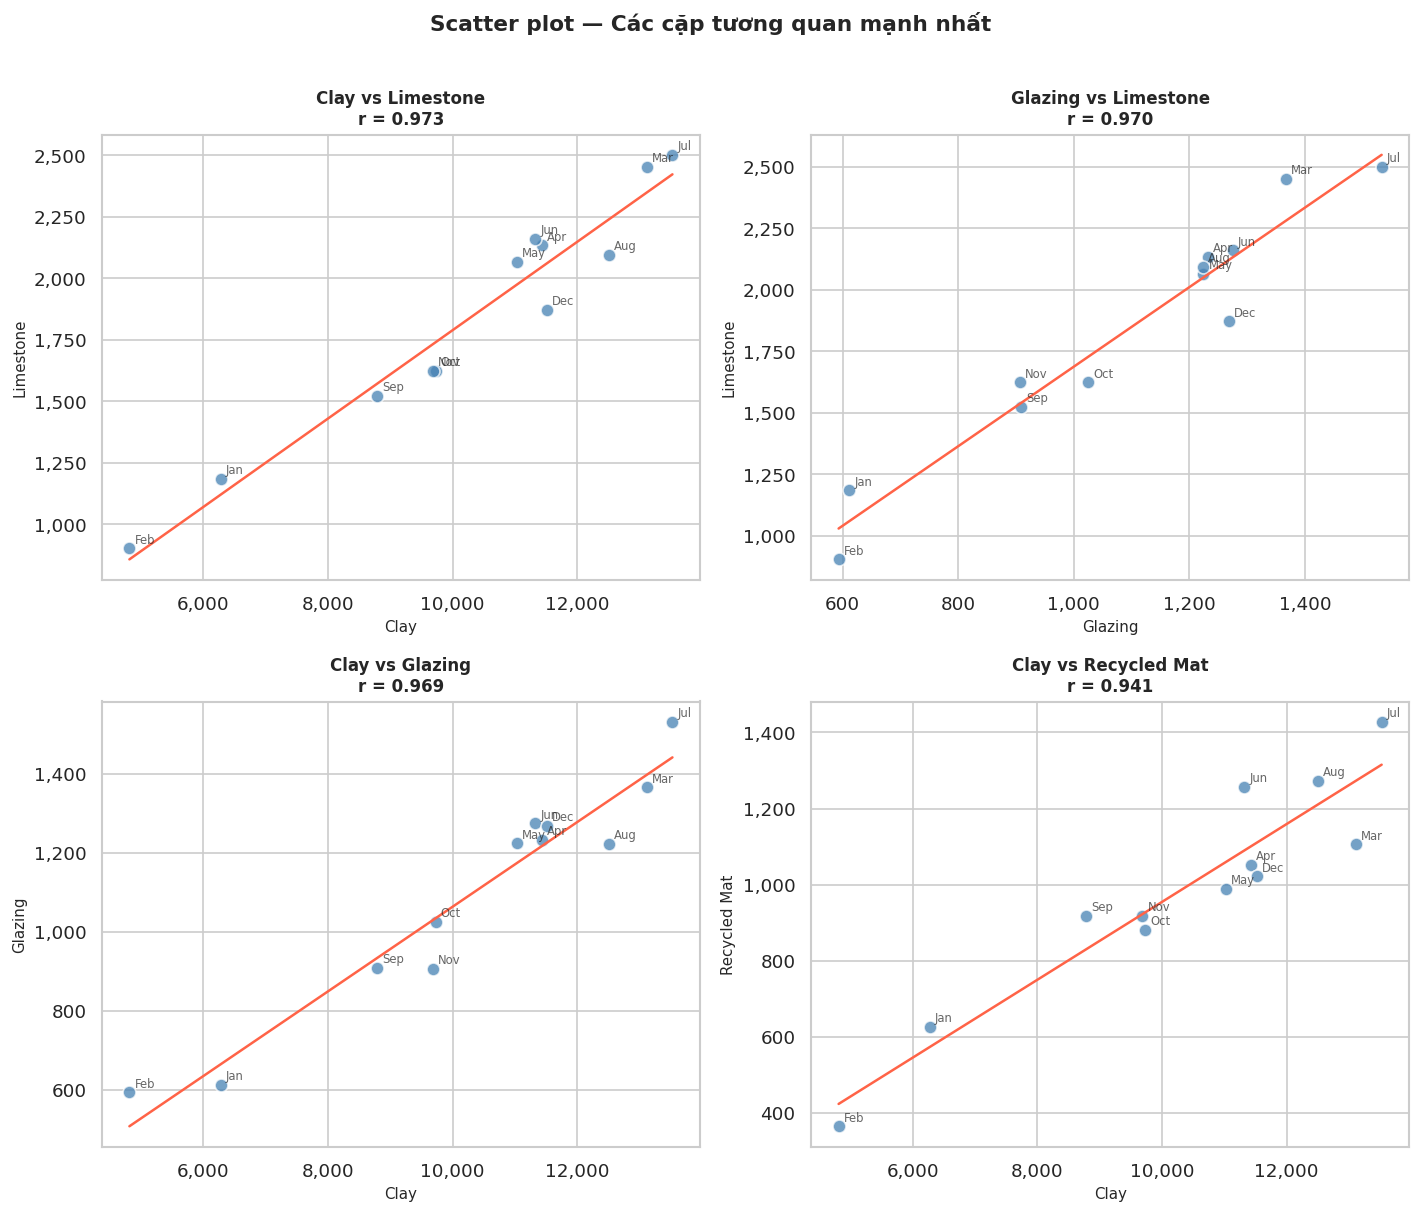

In [8]:
# Scatter plot các cặp tương quan mạnh nhất (top 4)
top4 = df_corr.head(4)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, row in top4.reset_index(drop=True).iterrows():
    a, b, r = row['Vật liệu A'], row['Vật liệu B'], row['Pearson r']
    x = pivot[a].fillna(0)
    y = pivot[b].fillna(0)
    axes[i].scatter(x, y, color='steelblue', alpha=0.75, s=60, edgecolors='white')
    m, b_coef, *_ = np.polyfit(x, y, 1, full=True) if len(x) > 1 else ([0, 0],)
    try:
        coeffs = np.polyfit(x, y, 1)
        xfit = np.linspace(x.min(), x.max(), 100)
        axes[i].plot(xfit, np.polyval(coeffs, xfit), color='tomato', linewidth=1.5)
    except:
        pass
    # Label từng điểm theo tháng
    for j, (xi, yi, m_name) in enumerate(zip(x, y, MONTHS)):
        axes[i].annotate(m_name, (xi, yi), fontsize=7, alpha=0.7,
                          xytext=(3, 3), textcoords='offset points')
    axes[i].set_xlabel(a, fontsize=9); axes[i].set_ylabel(b, fontsize=9)
    axes[i].set_title(f'{a} vs {b}\nr = {r:.3f}', fontsize=10, fontweight='bold')
    axes[i].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))

plt.suptitle('Scatter plot — Các cặp tương quan mạnh nhất', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

## 6. Ma trận tương quan — Spearman


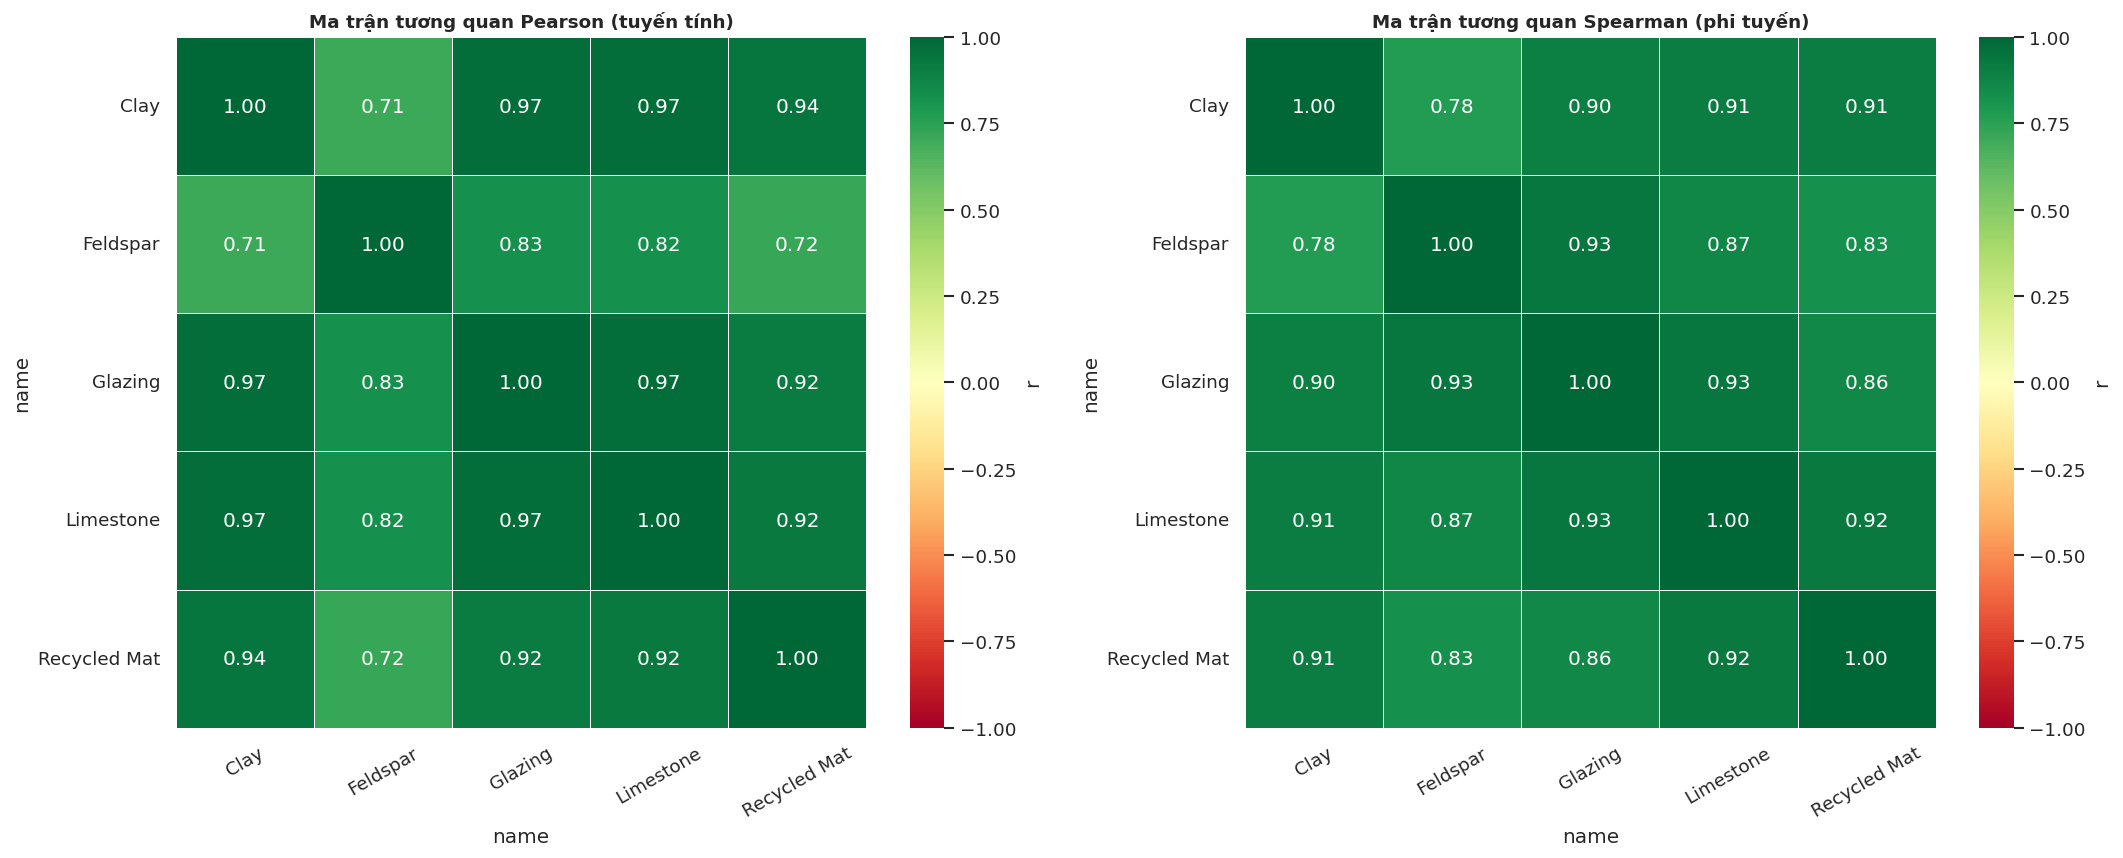

In [9]:
corr_sp = pivot[active_cols].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, corr_m, title in zip(axes,
    [corr, corr_sp],
    ['Pearson (tuyến tính)', 'Spearman (phi tuyến)']):
    sns.heatmap(corr_m, annot=True, fmt='.2f', cmap='RdYlGn',
                center=0, vmin=-1, vmax=1, linewidths=0.4, square=True,
                ax=ax, cbar_kws={'label': 'r'})
    ax.set_title(f'Ma trận tương quan {title}', fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout(); plt.show()

## 7. ANOVA — Sản lượng theo vật liệu & theo quý


In [10]:
groups = [df_monthly[df_monthly['name'] == m]['value'].dropna().values
          for m in active_cols]

F_stat, p_val = f_oneway(*groups)
print('='*55)
print('ONE-WAY ANOVA — Sản lượng theo loại vật liệu')
print('='*55)
print(f'  F-statistic : {F_stat:.4f}')
print(f'  p-value     : {p_val:.6f}')
print()
if p_val < 0.05:
    print('  p < 0.05 → Có sự khác biệt đáng kể giữa các vật liệu')
    print('   → Gợi ý: Mỗi vật liệu có pattern sản lượng riêng biệt')
else:
    print('  p ≥ 0.05 → Không có sự khác biệt đáng kể')

ONE-WAY ANOVA — Sản lượng theo loại vật liệu
  F-statistic : 127.5337
  p-value     : 0.000000

  p < 0.05 → Có sự khác biệt đáng kể giữa các vật liệu
   → Gợi ý: Mỗi vật liệu có pattern sản lượng riêng biệt


In [11]:
# Kruskal-Wallis (phi tham số — không giả định phân phối chuẩn)
H_stat, p_kw = kruskal(*[g for g in groups if len(g) > 0])
print('='*55)
print('KRUSKAL-WALLIS TEST (phi tham số)')
print('='*55)
print(f'  H-statistic : {H_stat:.4f}')
print(f'  p-value     : {p_kw:.6f}')
print()
if p_kw < 0.05:
    print('  p < 0.05 → Phân phối sản lượng khác nhau có ý nghĩa')
else:
    print('  p ≥ 0.05 → Không khác biệt đáng kể')

KRUSKAL-WALLIS TEST (phi tham số)
  H-statistic : 37.9284
  p-value     : 0.000000

  p < 0.05 → Phân phối sản lượng khác nhau có ý nghĩa


In [12]:
# ANOVA theo nhóm tháng (Q1 vs Q2 vs Q3 vs Q4)
quarter_map = {'Jan':'Q1','Feb':'Q1','Mar':'Q1',
               'Apr':'Q2','May':'Q2','Jun':'Q2',
               'Jul':'Q3','Aug':'Q3','Sep':'Q3',
               'Oct':'Q4','Nov':'Q4','Dec':'Q4'}
df_monthly['quarter'] = df_monthly['period'].astype(str).map(quarter_map)

q_groups = [df_monthly[df_monthly['quarter'] == q]['value'].dropna().values
            for q in ['Q1','Q2','Q3','Q4']]
F_q, p_q = f_oneway(*q_groups)
print('='*55)
print('ONE-WAY ANOVA — Sản lượng theo Quý')
print('='*55)
print(f'  F-statistic : {F_q:.4f}')
print(f'  p-value     : {p_q:.6f}')
if p_q < 0.05:
    print('  Có mùa vụ (seasonality) trong dữ liệu!')
else:
    print('  Không phát hiện mùa vụ rõ ràng.')

ONE-WAY ANOVA — Sản lượng theo Quý
  F-statistic : 0.1810
  p-value     : 0.909149
  Không phát hiện mùa vụ rõ ràng.


## 8. T-Test — So sánh từng cặp vật liệu


In [13]:
ttest_results = []
for m1, m2 in combinations(active_cols, 2):
    g1 = df_monthly[df_monthly['name'] == m1]['value'].dropna()
    g2 = df_monthly[df_monthly['name'] == m2]['value'].dropna()
    t, p = ttest_ind(g1, g2, equal_var=False)
    ttest_results.append({
        'Vật liệu A': m1, 'Vật liệu B': m2,
        't-stat': round(t, 3), 'p-value': round(p, 4),
        'p<0.05': 'Yes' if p < 0.05 else 'No'
    })

df_ttest = pd.DataFrame(ttest_results).sort_values('p-value')
n_tests = len(df_ttest)
alpha_bonf = 0.05 / n_tests if n_tests > 0 else 0.05
df_ttest['Bonferroni'] = df_ttest['p-value'].apply(lambda p: 'Yes' if p < alpha_bonf else 'No')

print(f'Welch t-test cho {n_tests} cặp vật liệu (n=12 tháng/vật liệu):')
print(f"  Có khác biệt đáng kể (p < 0.05, chưa điều chỉnh): {(df_ttest['p-value'] < 0.05).sum()} cặp")
print(f'  Bonferroni alpha = 0.05/{n_tests} = {alpha_bonf:.5f}')
print(f"  Có khác biệt (Bonferroni): {(df_ttest['p-value'] < alpha_bonf).sum()} cặp")
print()
print('Cảnh báo: Cỡ mẫu nhỏ (n=12) và dữ liệu time-series => kết quả mang tính exploratory.')
print('  Nhiều cặp "có khác biệt" khi chưa điều chỉnh có thể là false positive.')
print()
print('Top 10 cặp khác biệt rõ nhất:')
display(df_ttest.head(10))


Welch t-test cho 10 cặp vật liệu (n=12 tháng/vật liệu):
  Có khác biệt đáng kể (p < 0.05, chưa điều chỉnh): 7 cặp
  Bonferroni alpha = 0.05/10 = 0.00500
  Có khác biệt (Bonferroni): 6 cặp

Cảnh báo: Cỡ mẫu nhỏ (n=12) và dữ liệu time-series => kết quả mang tính exploratory.
  Nhiều cặp "có khác biệt" khi chưa điều chỉnh có thể là false positive.

Top 10 cặp khác biệt rõ nhất:


,Vật liệu A,Vật liệu B,t-stat,p-value,p<0.05,Bonferroni
0,Clay,Feldspar,11.615,0.0000,Yes,Yes
1,Clay,Glazing,12.007,0.0000,Yes,Yes
2,Clay,Limestone,10.916,0.0000,Yes,Yes
3,Clay,Recycled Mat,12.155,0.0000,Yes,Yes
9,Limestone,Recycled Mat,5.256,0.0001,Yes,Yes
7,Glazing,Limestone,-4.555,0.0002,Yes,Yes
5,Feldspar,Limestone,-2.747,0.0119,Yes,No
6,Feldspar,Recycled Mat,1.496,0.1537,No,No
8,Glazing,Recycled Mat,0.940,0.3575,No,No
4,Feldspar,Glazing,0.879,0.3921,No,No


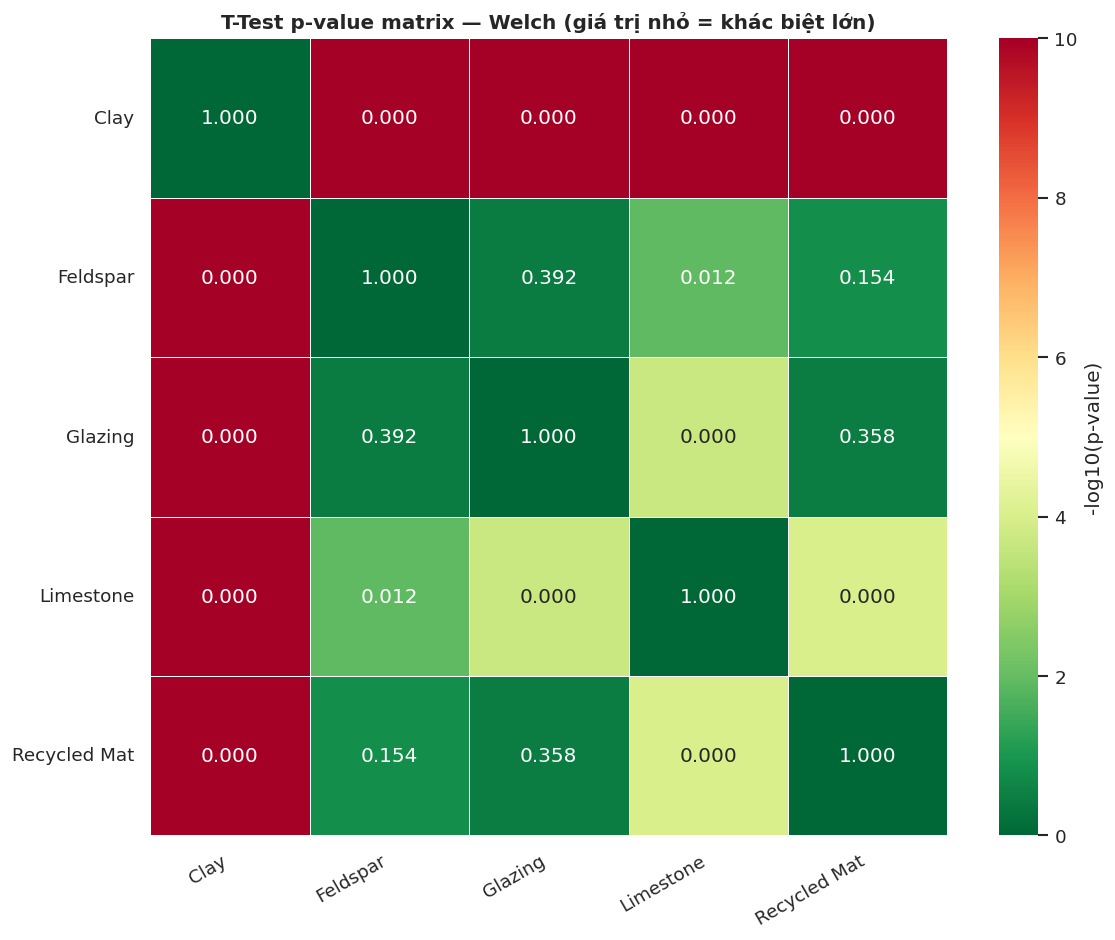

In [14]:
# Visualize p-value matrix (t-test)
mat_cols = list(active_cols)
p_matrix = pd.DataFrame(np.ones((len(mat_cols), len(mat_cols))),
                         index=mat_cols, columns=mat_cols)
for row in ttest_results:
    p_matrix.loc[row['Vật liệu A'], row['Vật liệu B']] = row['p-value']
    p_matrix.loc[row['Vật liệu B'], row['Vật liệu A']] = row['p-value']

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(-np.log10(p_matrix + 1e-10), annot=p_matrix.round(3),
            fmt='.3f', cmap='RdYlGn_r', linewidths=0.4,
            square=True, ax=ax, cbar_kws={'label': '-log10(p-value)'})
ax.set_title('T-Test p-value matrix — Welch (giá trị nhỏ = khác biệt lớn)',
             fontsize=12, fontweight='bold')
plt.xticks(rotation=30, ha='right'); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

## 9. Trend detection — Tương quan với thời gian


In [15]:
# Tương quan Spearman giữa từng vật liệu và số thứ tự tháng
time_corr = []
month_nums = np.arange(1, 13)

for col in active_cols:
    vals = pivot[col].fillna(0).values
    r, p = stats.spearmanr(month_nums, vals)
    trend = '📈 Tăng' if r > 0.3 and p < 0.1 else ('📉 Giảm' if r < -0.3 and p < 0.1 else '➡️ Ổn định')
    time_corr.append({'Vật liệu': col, 'Spearman r (vs tháng)': round(r, 3),
                       'p-value': round(p, 4), 'Xu hướng': trend})

df_trend = pd.DataFrame(time_corr).sort_values('Spearman r (vs tháng)', ascending=False)
print('Tương quan với thứ tự tháng — gợi ý xu hướng (trend):')
display(df_trend)

Tương quan với thứ tự tháng — gợi ý xu hướng (trend):


,Vật liệu,Spearman r (vs tháng),p-value,Xu hướng
0,Clay,0.189,0.5567,➡️ Ổn định
4,Recycled Mat,0.147,0.6488,➡️ Ổn định
2,Glazing,0.112,0.7292,➡️ Ổn định
3,Limestone,0.021,0.9484,➡️ Ổn định
1,Feldspar,-0.098,0.7621,➡️ Ổn định


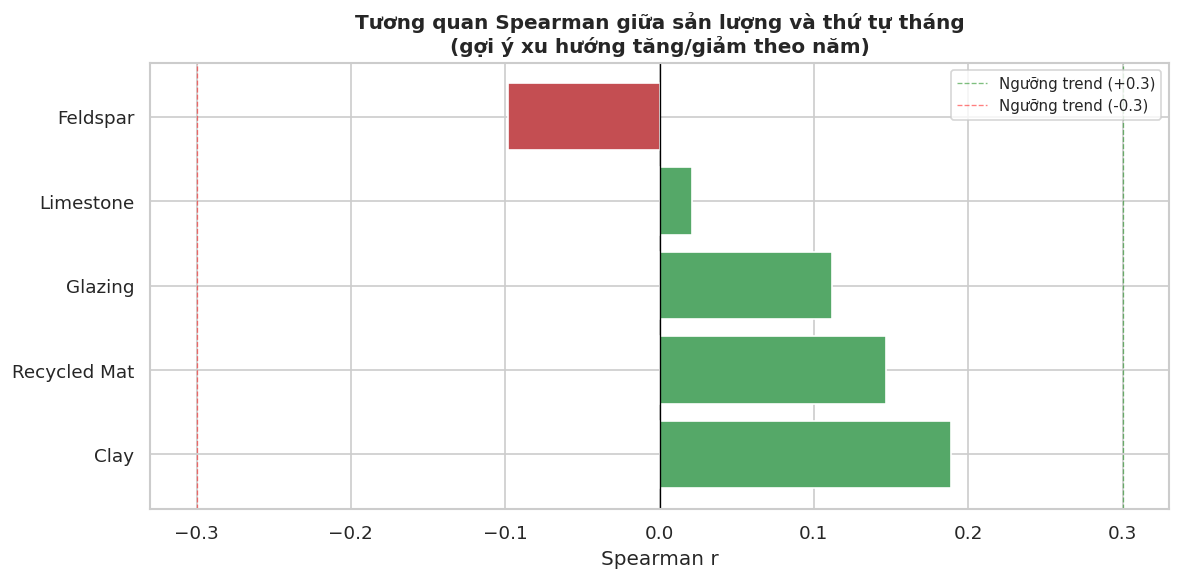

In [16]:
# Visualize trend
fig, ax = plt.subplots(figsize=(10, 5))
colors_trend = ['#C44E52' if r < 0 else '#55A868' for r in df_trend['Spearman r (vs tháng)']]
ax.barh(df_trend['Vật liệu'], df_trend['Spearman r (vs tháng)'], color=colors_trend, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline(0.3, color='green', linewidth=0.8, linestyle='--', alpha=0.5, label='Ngưỡng trend (+0.3)')
ax.axvline(-0.3, color='red', linewidth=0.8, linestyle='--', alpha=0.5, label='Ngưỡng trend (-0.3)')
ax.set_title('Tương quan Spearman giữa sản lượng và thứ tự tháng\n(gợi ý xu hướng tăng/giảm theo năm)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Spearman r')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

## 9b. Rolling Trend & Month-over-Month Growth


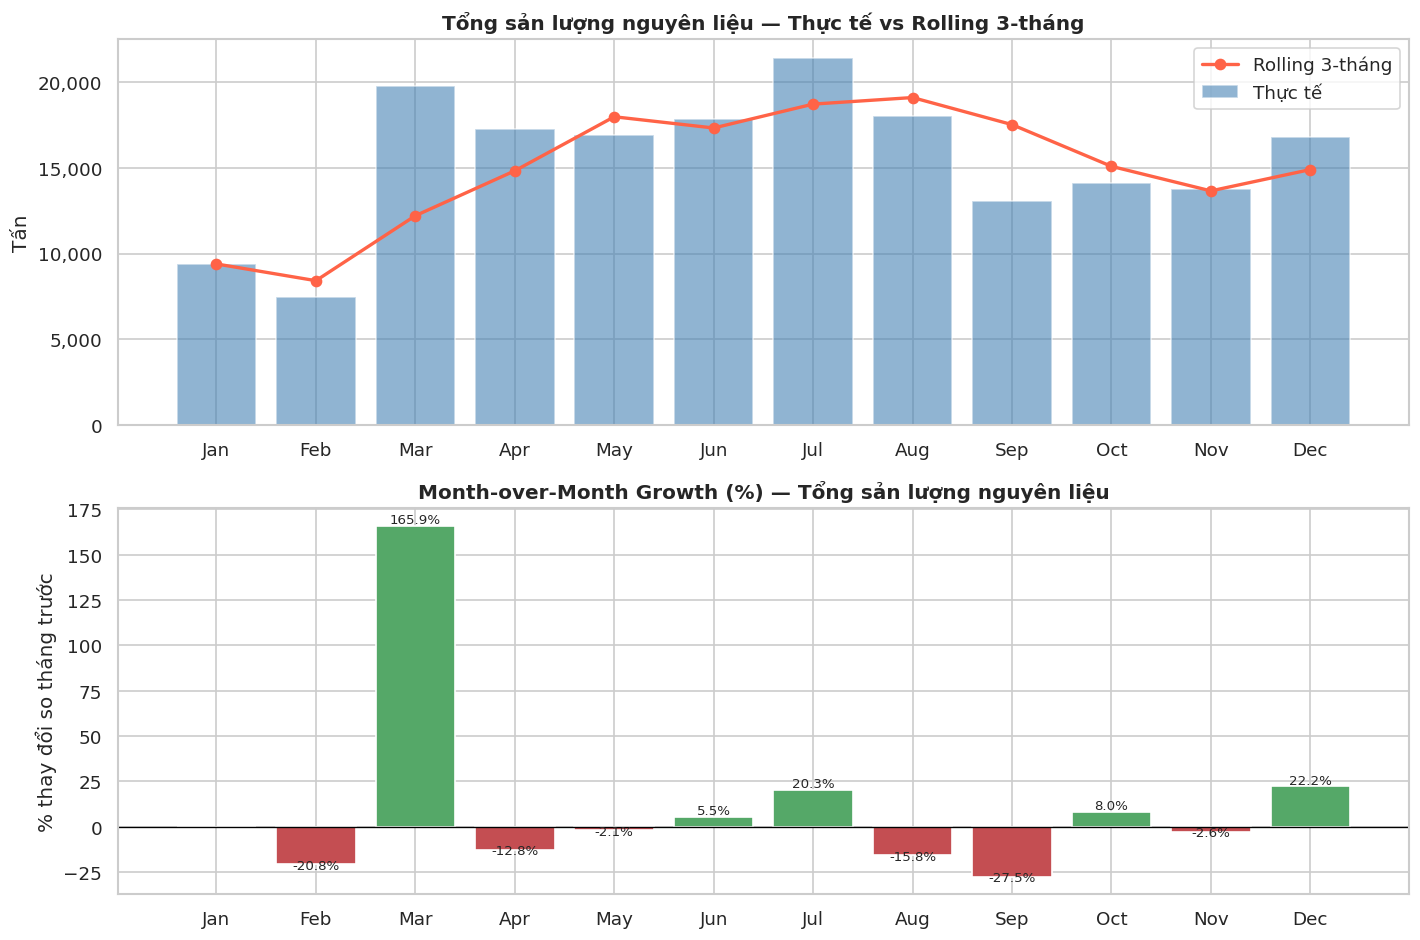

In [17]:
# Rolling trend & MoM growth cho tổng sản lượng nguyên liệu
monthly_total_series = df_monthly.groupby('period')['value'].sum().reindex(MONTHS)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Rolling 3-month mean
rolling3 = monthly_total_series.rolling(3, min_periods=1).mean()
axes[0].bar(monthly_total_series.index.astype(str), monthly_total_series.values, color='steelblue', alpha=0.6, label='Thực tế')
axes[0].plot(monthly_total_series.index.astype(str), rolling3.values, color='tomato', linewidth=2, marker='o', label='Rolling 3-tháng')
axes[0].set_title('Tổng sản lượng nguyên liệu — Thực tế vs Rolling 3-tháng', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Tấn')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
axes[0].legend()

# Month-over-Month growth
mom = monthly_total_series.pct_change() * 100
colors_mom = ['#55A868' if v >= 0 else '#C44E52' for v in mom.fillna(0)]
axes[1].bar(monthly_total_series.index.astype(str), mom.fillna(0), color=colors_mom, edgecolor='white')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Month-over-Month Growth (%) — Tổng sản lượng nguyên liệu', fontsize=12, fontweight='bold')
axes[1].set_ylabel('% thay đổi so tháng trước')
for i, (m, v) in enumerate(zip(monthly_total_series.index.astype(str), mom.fillna(0))):
    if i > 0:
        axes[1].text(i, v + (1.5 if v >= 0 else -2.5), f'{v:.1f}%', ha='center', fontsize=8)

plt.tight_layout(); plt.show()


## 9c. Cơ cấu nguyên liệu theo tháng


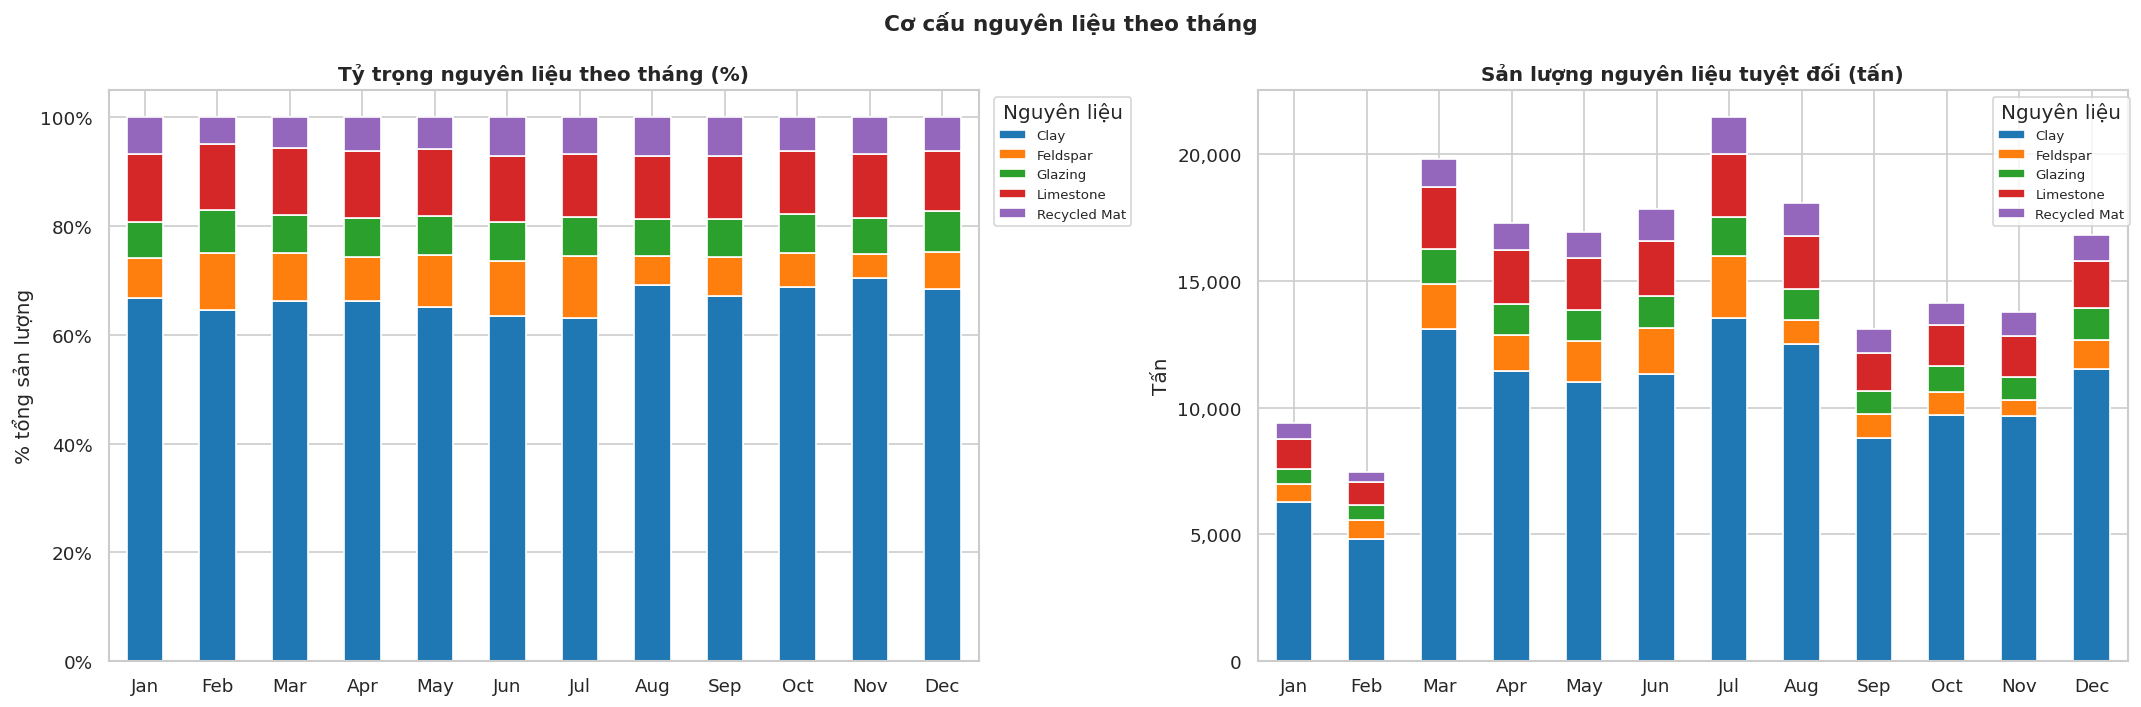

Tỷ trọng trung bình cả năm theo vật liệu:


name,Clay,Limestone,Feldspar,Glazing,Recycled Mat
% trung bình,66.6,11.9,8.0,7.1,6.3


In [18]:
# Cơ cấu nguyên liệu: tỷ trọng % theo tháng
pivot_active = pivot[active_cols].copy()
row_total = pivot_active.sum(axis=1).replace(0, np.nan)
prop_pct = pivot_active.div(row_total, axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Stacked bar - tỷ trọng %
prop_pct.plot(kind='bar', stacked=True, ax=axes[0], edgecolor='white')
axes[0].set_title('Tỷ trọng nguyên liệu theo tháng (%)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('% tổng sản lượng')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Nguyên liệu', bbox_to_anchor=(1.01, 1), fontsize=8)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}%'))

# Absolute volume stacked
pivot_active.plot(kind='bar', stacked=True, ax=axes[1], edgecolor='white')
axes[1].set_title('Sản lượng nguyên liệu tuyệt đối (tấn)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Tấn')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Nguyên liệu', bbox_to_anchor=(1.01, 1), fontsize=8)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))

plt.suptitle('Cơ cấu nguyên liệu theo tháng', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print('Tỷ trọng trung bình cả năm theo vật liệu:')
avg_prop = prop_pct.mean().sort_values(ascending=False).round(1)
display(avg_prop.to_frame('% trung bình').T)


## 10. Outliers — IQR & Z-Score


In [19]:
# --- IQR Method ---
iqr_results = []
for mat in active_cols:
    sub = df_monthly[df_monthly['name'] == mat][['period', 'value']].copy()
    Q1, Q3 = sub['value'].quantile(0.25), sub['value'].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outs = sub[(sub['value'] < lower) | (sub['value'] > upper)]
    for _, row in outs.iterrows():
        iqr_results.append({'Method': 'IQR', 'Vật liệu': mat,
                             'Tháng': str(row['period']), 'value': row['value'],
                             'lower': round(lower,2), 'upper': round(upper,2),
                             'Khuyến nghị': 'Điều tra thêm — có thể do seasonality hoặc kế hoạch vận hành'})

# --- Z-Score Method ---
zscore_results = []
for mat in active_cols:
    sub = df_monthly[df_monthly['name'] == mat][['period', 'value']].copy()
    if sub['value'].std() == 0:
        continue
    sub['z'] = np.abs(stats.zscore(sub['value'].fillna(sub['value'].mean())))
    outs = sub[sub['z'] > 2.5]
    for _, row in outs.iterrows():
        zscore_results.append({'Method': 'Z-Score', 'Vật liệu': mat,
                               'Tháng': str(row['period']), 'value': row['value'],
                               'z-score': round(row['z'], 3),
                               'Khuyến nghị': 'Điều tra thêm — có thể do seasonality hoặc kế hoạch vận hành'})

print(f'IQR method    => {len(iqr_results)} outlier(s)')
print(f'Z-Score (>2.5) => {len(zscore_results)} outlier(s)')

if iqr_results:
    print('\nOutliers theo IQR:')
    display(pd.DataFrame(iqr_results))
if zscore_results:
    print('\nOutliers theo Z-Score:')
    display(pd.DataFrame(zscore_results))
if not iqr_results and not zscore_results:
    print('\nKhông phát hiện outlier đáng kể.')


IQR method    => 2 outlier(s)
Z-Score (>2.5) => 0 outlier(s)

Outliers theo IQR:


,Method,Vật liệu,Tháng,value,lower,upper,Khuyến nghị
0,IQR,Clay,Feb,4812.60,6005.50,15221.62,Điều tra thêm — có thể do seasonality hoặc kế ...
1,IQR,Recycled Mat,Feb,364.14,555.12,1496.70,Điều tra thêm — có thể do seasonality hoặc kế ...


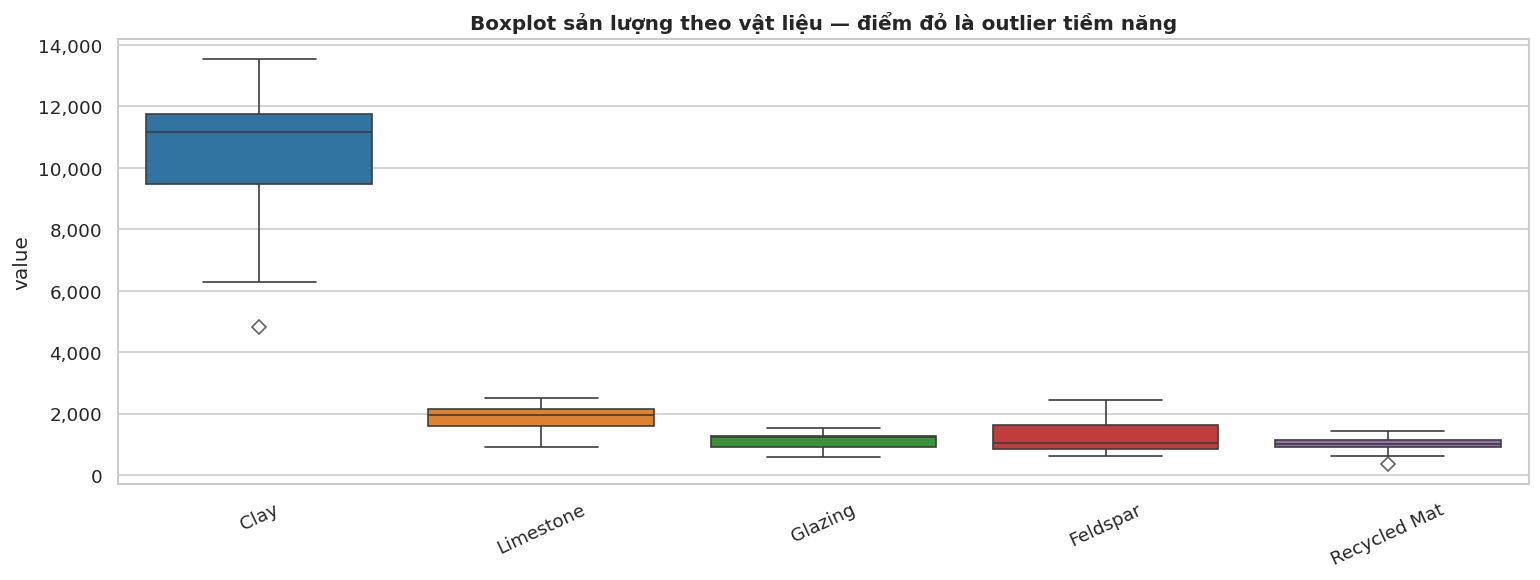

In [20]:
# Boxplot toàn bộ theo vật liệu — highlight outlier
df_nonzero = df_monthly[df_monthly['value'] > 0]
order_box = df_nonzero.groupby('name')['value'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(13, 5))
sns.boxplot(data=df_nonzero, x='name', y='value', order=order_box,
            palette='tab10', ax=ax,
            flierprops=dict(marker='D', color='red', markersize=6, alpha=0.8, label='Outlier'))
ax.set_title('Boxplot sản lượng theo vật liệu — điểm đỏ là outlier tiềm năng',
             fontsize=12, fontweight='bold')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=25)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
plt.tight_layout(); plt.show()

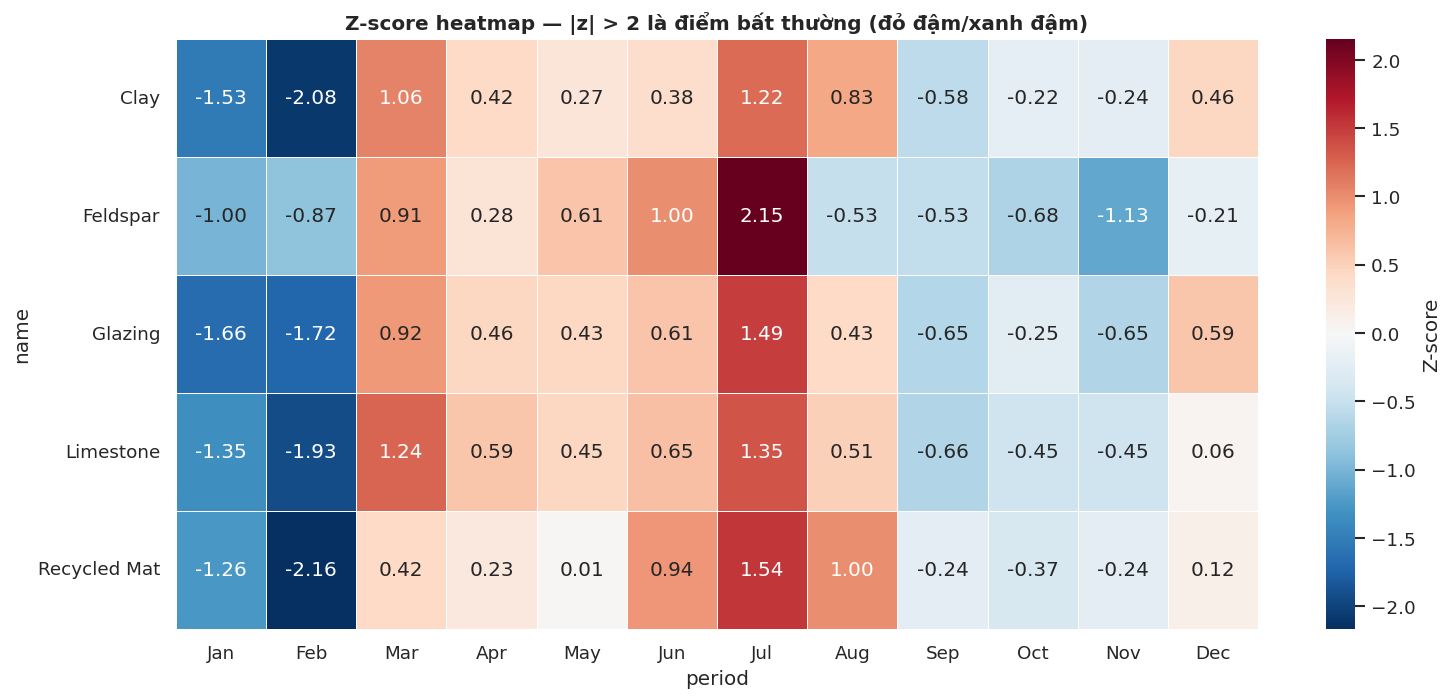

In [21]:
# Z-score heatmap — xem mức độ bất thường từng tháng
zscore_pivot = pivot[active_cols].apply(
    lambda col: (col - col.mean()) / col.std() if col.std() > 0 else col * 0
)

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(zscore_pivot.T, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.4, ax=ax, cbar_kws={'label': 'Z-score'})
ax.set_title('Z-score heatmap — |z| > 2 là điểm bất thường (đỏ đậm/xanh đậm)',
             fontsize=12, fontweight='bold')
plt.yticks(rotation=0); plt.tight_layout(); plt.show()

## 11. Clustering tháng & vật liệu


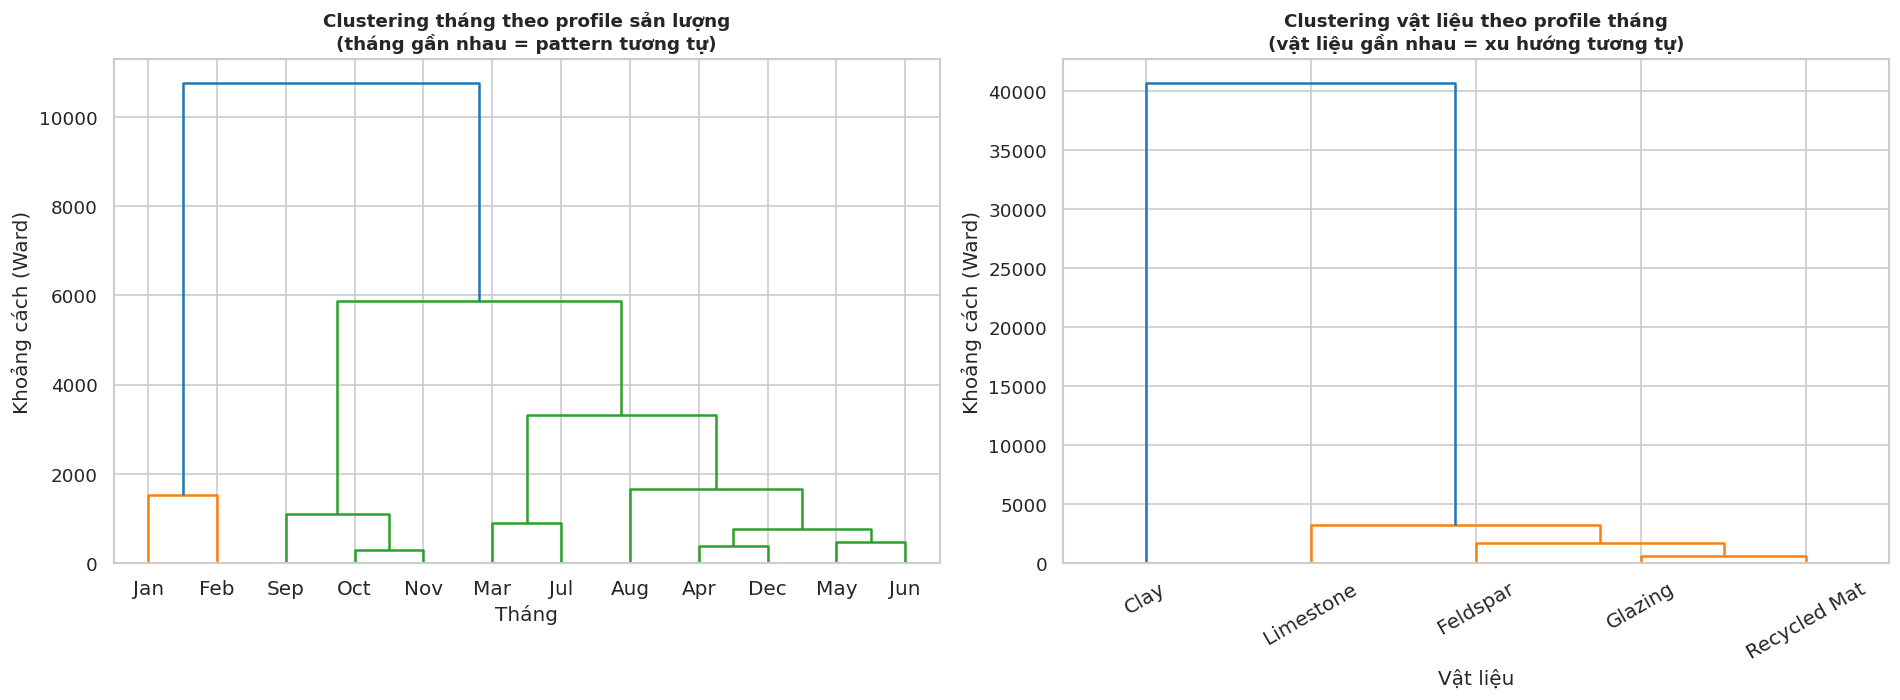

In [22]:
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

pivot_filled = pivot[active_cols].fillna(0)

# Clustering các THÁNG
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Dendrogram tháng
Z_months = linkage(pivot_filled.values, method='ward')
dendrogram(Z_months, labels=list(pivot_filled.index.astype(str)),
           ax=axes[0], color_threshold=0.7*max(Z_months[:,2]))
axes[0].set_title('Clustering tháng theo profile sản lượng\n(tháng gần nhau = pattern tương tự)',
                   fontsize=11, fontweight='bold')
axes[0].set_xlabel('Tháng')
axes[0].set_ylabel('Khoảng cách (Ward)')

# Dendrogram vật liệu
Z_mats = linkage(pivot_filled.T.values, method='ward')
dendrogram(Z_mats, labels=list(active_cols),
           ax=axes[1], color_threshold=0.7*max(Z_mats[:,2]),
           leaf_rotation=30)
axes[1].set_title('Clustering vật liệu theo profile tháng\n(vật liệu gần nhau = xu hướng tương tự)',
                   fontsize=11, fontweight='bold')
axes[1].set_xlabel('Vật liệu')
axes[1].set_ylabel('Khoảng cách (Ward)')

plt.tight_layout(); plt.show()